<a href="https://colab.research.google.com/github/marlborito117-maker/conectatel-customer-analysis/blob/main/notebooks/conectatel_customer_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


In [ ]:
# convertir fechas a datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# verificar cambios en users
users.info()

# verificar cambios en usage
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  0 non-null      datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 250.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   

## 📊 Conversión y validación de fechas

Se realizó la conversión de las columnas de fecha (`reg_date`, `churn_date` y `date`) al tipo `datetime`, utilizando el parámetro `errors='coerce'` para manejar posibles valores inválidos.

Posteriormente, se verificó la conversión mediante `.info()`, confirmando que las columnas ahora tienen el tipo de dato correcto (`datetime64[ns]`).

### 🔹 Hallazgos relevantes:

- La columna `reg_date` se convirtió correctamente sin pérdida de datos.
- La columna `date` en el dataset `usage` presenta algunos valores nulos tras la conversión, lo que indica la existencia de fechas inválidas en los datos originales.
- La columna `churn_date` quedó completamente nula, lo que sugiere que:
  - los valores originales no estaban en un formato de fecha válido, o  
  - representan usuarios que no han cancelado el servicio (nulos estructurales).

### 🔹 Conclusión:

La conversión de tipos fue exitosa y permite continuar con el análisis temporal. Los valores nulos identificados serán considerados en etapas posteriores para su correcta interpretación.

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("Cantidad de valores nulos:")
print(users.isna().sum())

print("\nProporción de valores nulos:")
print(users.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    4000
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    1.00000
dtype: float64


In [ ]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isna().sum())

print("\nProporción de valores nulos:")
print(usage.isna().mean())

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

## 📊 Revisión de valores nulos

Se analizaron los valores faltantes en los datasets `users` y `usage`, evaluando tanto su cantidad como su proporción.

### 🔹 Dataset: users

Se identificaron valores nulos en:

- `city`: 469 valores nulos (~11.7%).  
  **Acción:** al ser un porcentaje moderado, se puede evaluar imputación o mantener como nulo dependiendo del análisis.

- `churn_date`: 4000 valores nulos (100%).  
  **Interpretación:** estos valores son estructurales, ya que representan usuarios que no han cancelado el servicio.  
  **Acción:** no imputar ni eliminar.

---

### 🔹 Dataset: usage

Se identificaron valores nulos en:

- `date`: 50 valores nulos (~0.12%).  
  **Acción:** al ser un porcentaje muy bajo, se puede eliminar o ignorar sin impacto significativo.

- `duration`: 22076 valores nulos (~55.2%)  
- `length`: 17896 valores nulos (~44.7%)

Estos valores faltantes no representan errores, sino que dependen del tipo de evento (`type`):

- Las llamadas (`call`) utilizan `duration`
- Los mensajes (`message`) utilizan `length`

Por lo tanto, estos nulos son **estructurales**.

**Acción:** no imputar ni eliminar, sino considerar esta lógica en el análisis.

---

### 🔹 Conclusión

La mayoría de los valores nulos identificados son estructurales y no representan problemas de calidad de datos. Se continuará el análisis respetando la naturaleza de cada variable y aplicando tratamientos específicos solo donde sea necesario.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# resumen estadístico de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



### 🔹 Columnas numéricas (users)

- `user_id`: corresponde a un identificador único, por lo que no requiere análisis de valores atípicos.

- `age`: se detectó un valor mínimo de **-999**, lo cual es inválido para esta variable.

  **Interpretación:** este valor corresponde a un sentinel utilizado para representar datos faltantes o erróneos.

  **Acción:** reemplazar el valor -999 por valores nulos (`NaN`) para su posterior tratamiento.

In [ ]:
# reemplazar sentinel en age
users['age'] = users['age'].replace(-999, np.nan)

In [ ]:
users['age'].describe()

count    3945.000000
mean       48.137896
std        17.812830
min        18.000000
25%        33.000000
50%        48.000000
75%        64.000000
max        79.000000
Name: age, dtype: float64

Se identificaron 55 registros con el valor -999, los cuales fueron tratados como valores faltantes.

In [ ]:
# resumen estadístico de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


### 🔹 Columnas numéricas (usage)

- `id` y `user_id`: corresponden a identificadores únicos, por lo que no requieren análisis de valores atípicos.

- `duration`: no presenta valores negativos. Sin embargo, se identifican valores en 0, lo cual podría representar llamadas fallidas o registros incompletos. El valor máximo (120) se considera razonable dentro del contexto.

- `length`: no presenta valores negativos, pero contiene valores en 0, lo cual podría indicar mensajes vacíos o errores de registro. Asimismo, se observan valores máximos elevados (hasta 1490), lo que sugiere la presencia de posibles outliers, aunque estos podrían ser válidos dependiendo del tipo de mensaje.

---

### 🔹 Conclusión

No se identificaron sentinels evidentes en las columnas numéricas de `usage`. Sin embargo, se detectaron valores en 0 y valores altos que requieren análisis adicional para determinar si corresponden a comportamiento real del usuario o posibles anomalías.

In [ ]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nValores únicos en {col}:")
    print(users[col].value_counts())



Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64



### 🔹 Columnas categóricas (users)

- `city`: presenta múltiples valores correspondientes a diferentes ciudades. Sin embargo, se identificó el valor `"?"` en 96 registros, lo cual no corresponde a una ciudad válida.

  **Interpretación:** este valor representa un sentinel utilizado para indicar datos faltantes o desconocidos.

  **Acción:** reemplazar el valor `"?"` por valores nulos (`NaN`) para su posterior tratamiento.

- `plan`: contiene dos valores (`Basico` y `Premium`), lo cual es consistente con los planes disponibles. No se detectan inconsistencias.

In [ ]:
# reemplazar sentinel en city
users['city'] = users['city'].replace('?', np.nan)

In [ ]:
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

Se identificaron 96 registros con el valor `"?"`, los cuales fueron tratados como valores faltantes, incrementando el total de valores nulos en la columna `city` a 565 registros.

In [ ]:
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

### 🔹 Columna categórica (usage)

- `type`: presenta dos valores (`call` y `text`). Sin embargo, el valor `text` parece representar mensajes, lo cual genera una inconsistencia en la nomenclatura esperada (`message`).

  **Interpretación:** existe una falta de estandarización en los valores categóricos.

  **Acción:** unificar los valores reemplazando `text` por `message` para mantener consistencia en el dataset.


In [ ]:
# estandarizar valores de type
usage['type'] = usage['type'].replace('text', 'message')

In [ ]:
usage['type'].value_counts()

message    22092
call       17908
Name: type, dtype: int64


## 📊 Valores inválidos o sentinels

Se identificaron problemas de calidad de datos en las siguientes columnas:

- `age`: se detectó el valor -999, el cual fue tratado como valor faltante (`NaN`), ya que corresponde a un sentinel utilizado para representar datos erróneos.

- `city`: se identificó el valor `"?"` en 96 registros, el cual fue reemplazado por valores nulos (`NaN`) al representar datos desconocidos.

- `type`: se detectó una inconsistencia en los valores categóricos (`text` y `call`). Se estandarizó reemplazando `text` por `message` para mantener coherencia en el dataset.

---

## 🔹 Conclusión

Los valores inválidos detectados fueron tratados adecuadamente mediante conversión a nulos o estandarización, asegurando la consistencia y calidad del dataset para el análisis posterior.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# asegurar formato datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# años en reg_date
users['reg_year'] = users['reg_date'].dt.year
print(users['reg_year'].value_counts().sort_index())


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_year, dtype: int64


En `reg_date` se identificaron los años 2022, 2023 y 2024 como valores esperados. Sin embargo, se detectaron 40 registros con el año 2026, lo cual representa una inconsistencia al tratarse de fechas fuera del rango del dataset.

In [ ]:
# años en usage
usage['usage_year'] = usage['date'].dt.year
print(usage['usage_year'].value_counts().sort_index())


2024.0    39950
Name: usage_year, dtype: int64


En `date` se observa que todos los registros corresponden al año 2024, lo cual es consistente con el periodo de análisis. No se detectan fechas fuera de rango ni inconsistencias temporales.

## 📊 Fechas fuera de rango

Se realizó la validación de las columnas de fecha para identificar posibles inconsistencias temporales.

- En `reg_date` se detectaron 40 registros con el año 2026, lo cual representa un valor fuera del rango esperado, ya que los datos están definidos hasta el año 2024.

- En `date` (usage) no se identificaron inconsistencias, ya que todos los registros corresponden al año 2024.

---

### 🔹 Interpretación

Los registros con año 2026 en `reg_date` corresponden a fechas futuras, lo que indica un error de captura o inconsistencia en los datos.

---

### 🔹 Acción recomendada

Se recomienda tratar estos registros como inválidos, convirtiéndolos a valores nulos (`NaT`) para evitar afectar el análisis temporal, sin perder información del resto del registro.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# calcular mediana
age_mediana = users['age'].median()

# reemplazar valores nulos (ya convertiste -999 antes)
users['age'] = users['age'].fillna(age_mediana)

# verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# reemplazar sentinel en city
users['city'] = users['city'].replace('?', pd.NA)

# verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# convertir fechas futuras a NaT
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# verificar relación entre type y duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())


type
call       0.000000
message    0.999276
Name: duration, dtype: float64

In [ ]:
# verificar relación entre type y length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())


type
call       0.99933
message    0.00000
Name: length, dtype: float64

## 📊 Verificación de valores nulos en `duration` y `length`

Se analizó la relación entre los valores nulos y la variable `type` para determinar si los datos faltantes son aleatorios.

### 🔹 Resultados

- En `duration`, el 99.9% de los valores nulos se concentran en registros donde el tipo es `message`, mientras que en `call` no hay valores nulos.

- En `length`, el 99.9% de los valores nulos se concentran en registros donde el tipo es `call`, mientras que en `message` no hay valores nulos.

---

### 🔹 Interpretación

Los valores nulos no son aleatorios (MAR), sino que dependen directamente del tipo de evento:

- Las llamadas (`call`) utilizan la variable `duration`
- Los mensajes (`message`) utilizan la variable `length`

Esto indica que los nulos son **estructurales**, ya que cada variable aplica únicamente a un tipo específico de registro.

---

### 🔹 Acción

Se decide mantener los valores nulos sin imputación, ya que representan correctamente la estructura de los datos y no constituyen un problema de calidad.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_message"] = (usage["type"] == "message").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# agrupar por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_message": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_message,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_message": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
cols_num = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

user_profile[cols_num].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

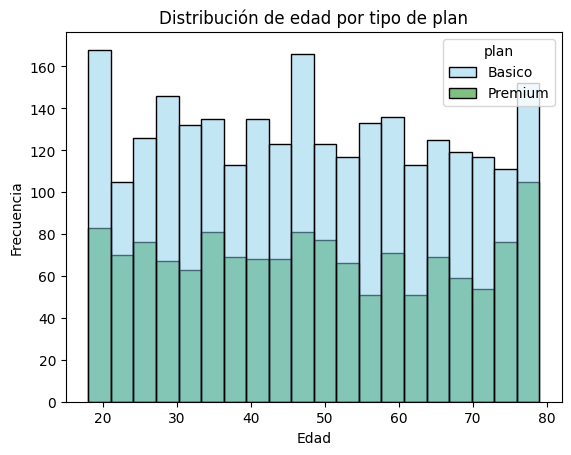

In [ ]:
# Histograma para visualizar la edad (age)
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
### 📊 Distribución de edad (age)

La distribución de la edad es relativamente uniforme a lo largo del rango (18 a 79 años), sin una concentración marcada en un grupo específico, lo que indica una distribución cercana a uniforme y sin sesgo evidente.

Al comparar por tipo de plan, no se observan diferencias significativas entre usuarios de plan Básico y Premium, ya que ambos presentan patrones similares en todos los rangos de edad.

---

### 🔹 Insight

La edad no parece ser un factor determinante en la elección del plan, lo que sugiere que el comportamiento de consumo dependerá más del uso del servicio que de características demográficas.


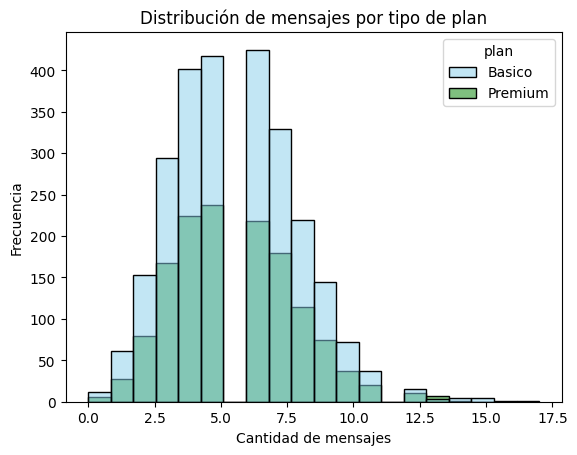

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
### 📊 Distribución de mensajes (cant_mensajes)

La distribución de mensajes presenta una forma aproximadamente simétrica, con una ligera concentración entre 3 y 7 mensajes por usuario, lo que indica un uso moderado del servicio.

Al comparar por tipo de plan, se observa que ambos (Básico y Premium) presentan patrones muy similares, sin diferencias marcadas en la cantidad de mensajes enviados.

Sin embargo, se identifica una ligera cola hacia la derecha, lo que sugiere la existencia de algunos usuarios con mayor actividad en mensajería.

---

### 🔹 Insight

El comportamiento de envío de mensajes es relativamente homogéneo entre los tipos de plan, lo que indica que este servicio no es un factor diferenciador clave entre usuarios Básico y Premium.

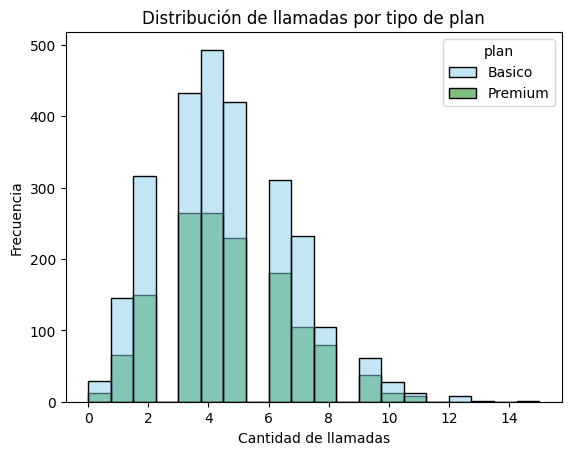

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
### 📊 Distribución de llamadas (cant_llamadas)

La distribución de llamadas presenta una forma aproximadamente simétrica, con una ligera concentración entre 3 y 6 llamadas por usuario, lo que indica un uso moderado del servicio.

Al comparar por tipo de plan, se observa que los usuarios de ambos planes (Básico y Premium) muestran patrones muy similares, aunque los usuarios del plan Básico presentan una mayor frecuencia en todos los rangos, lo cual es consistente con su mayor proporción dentro del dataset.

Se observa una ligera cola hacia la derecha, indicando la presencia de algunos usuarios con mayor número de llamadas.

---

### 🔹 Insight

El número de llamadas no muestra diferencias significativas entre los tipos de plan, lo que sugiere que este comportamiento no es un factor determinante en la segmentación de usuarios entre Básico y Premium.

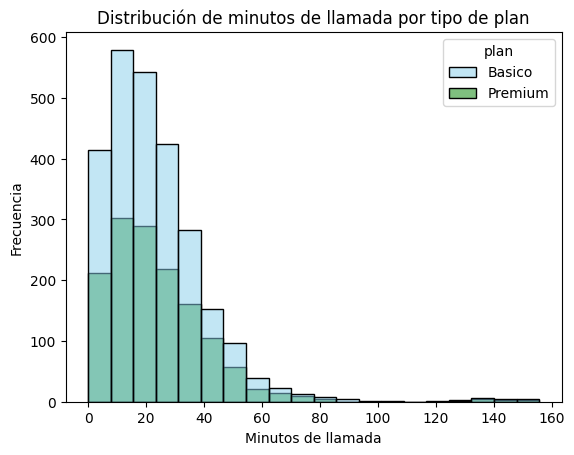

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de minutos de llamada por tipo de plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
### 📊 Distribución de minutos de llamada (cant_minutos_llamada)

La distribución de minutos de llamada presenta un sesgo marcado hacia la derecha, con una alta concentración de usuarios en rangos bajos (0 a 30 minutos) y una cola larga que alcanza valores cercanos a 150 minutos.

Esto indica la presencia de usuarios intensivos (heavy users) que consumen significativamente más minutos que el promedio.

Al comparar por tipo de plan, se observa que los usuarios del plan Premium tienen mayor presencia relativa en los rangos altos de consumo, mientras que los usuarios del plan Básico se concentran principalmente en niveles bajos y moderados.

---

### 🔹 Insight

El consumo de minutos de llamada es el principal diferenciador entre usuarios, ya que permite identificar claramente a los usuarios intensivos, quienes tienden a concentrarse en el plan Premium.

Esto sugiere una oportunidad para estrategias de upselling, promoviendo la migración de usuarios con alto consumo desde el plan Básico hacia planes Premium.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

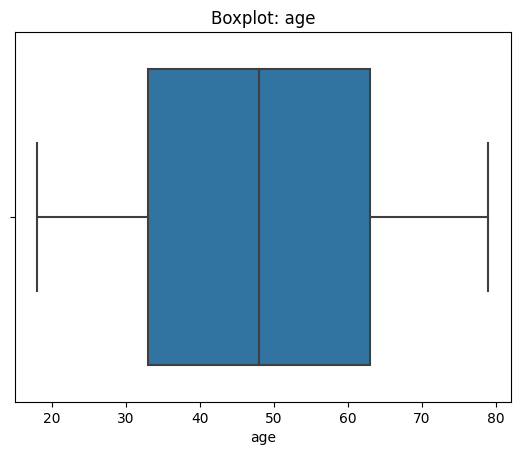

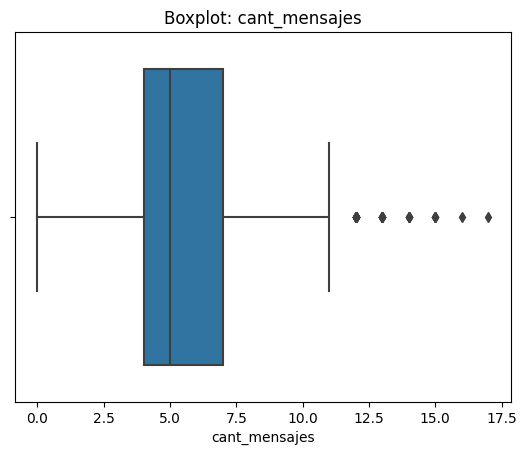

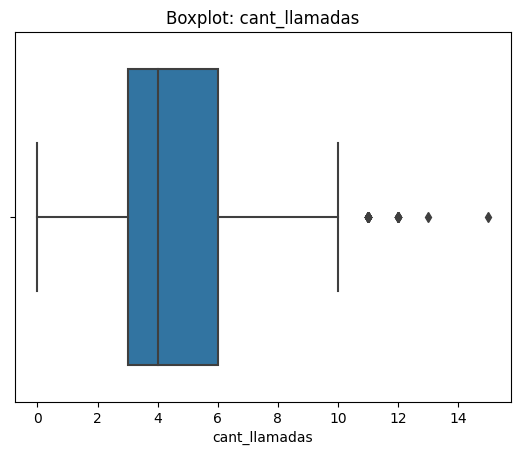

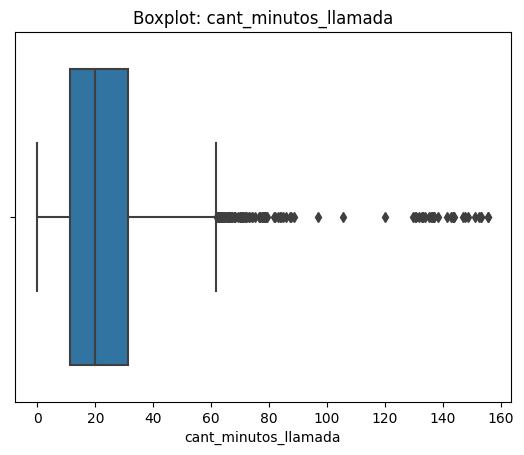

In [ ]:
# columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure()
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

🔍 **Insights:**

- **age:**  
  No se observan outliers. La distribución se mantiene dentro del rango esperado (**18 a 80 años**), mostrando un comportamiento estable y consistente.  
  Por lo tanto, **no requiere tratamiento adicional**.

- **cant_mensajes:**  
  Se identifican outliers en la parte superior (**valores mayores a ~11 mensajes**).  
  Sin embargo, estos valores son **plausibles dentro del comportamiento de uso**, representando usuarios más activos, por lo que se consideran **válidos** y **no se recomienda eliminarlos**.

- **cant_llamadas:**  
  Presenta algunos outliers altos (**mayores a ~10 llamadas**).  
  Al igual que en mensajes, estos valores corresponden a usuarios con **mayor nivel de uso**, por lo que se **mantienen en el análisis**.

- **cant_minutos_llamada:**  
  Se observan numerosos outliers en la cola derecha (**valores superiores a ~60 minutos**), lo que indica una **distribución fuertemente sesgada a la derecha**.  
  Estos valores reflejan usuarios intensivos del servicio, por lo que **no representan errores** y deben **conservarse**.

In [ ]:
# columnas a analizar (solo las que tienen outliers)
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# calcular límites IQR
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f"\n{col}:")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Límite inferior: {limite_inferior}")
    print(f"Límite superior: {limite_superior}")




cant_mensajes:
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite inferior: -0.5
Límite superior: 11.5

cant_llamadas:
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite inferior: -1.5
Límite superior: 10.5

cant_minutos_llamada:
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite inferior: -19.322500000000005
Límite superior: 61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


🔍 **Insights:**

- **cant_mensajes:**  
  El límite superior calculado es **11.5**, mientras que el valor máximo observado es **17**, lo que confirma la presencia de outliers.  
  Sin embargo, estos valores representan usuarios con **alta actividad de mensajería**, por lo que se consideran **comportamientos reales** y se **mantienen en el análisis**.

- **cant_llamadas:**  
  El límite superior es **10.5** y el valor máximo alcanza **15**, indicando la existencia de outliers.  
  No obstante, estos corresponden a usuarios con **uso intensivo del servicio**, por lo que **no se consideran errores** y se **conservan**.

- **cant_minutos_llamada:**  
  El límite superior es **61.86**, pero el valor máximo observado es **155.69**, evidenciando una **fuerte presencia de outliers** y una **distribución sesgada a la derecha**.  
  Estos valores reflejan usuarios altamente activos, por lo que se **mantienen** para no perder información relevante del comportamiento real.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso

def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,2022,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT,2022,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,2022,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,2022,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,2022,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad

def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,2022,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaT,2022,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,2022,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,2022,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,2022,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

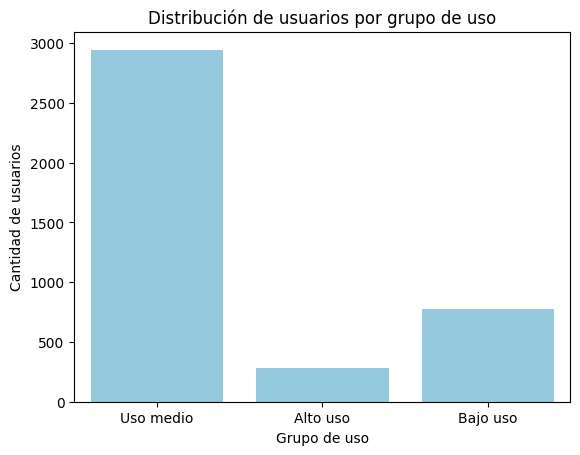

In [ ]:
# Visualización de los segmentos por uso
import seaborn as sns
import matplotlib.pyplot as plt

# Gráfico de grupo_uso
sns.countplot(data=user_profile, x='grupo_uso', color='skyblue')

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

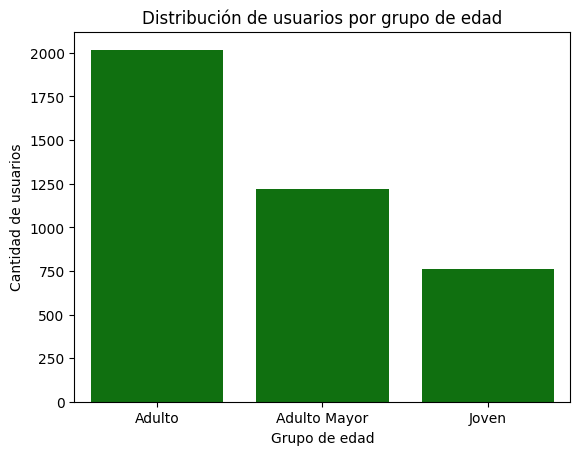

In [ ]:
# Gráfico de grupo_edad
sns.countplot(data=user_profile, x='grupo_edad', color='green')

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

### ⚠️ Problemas detectados en los datos

- En la columna `age` se detectaron **55 registros** con el valor **-999**, equivalente a aproximadamente **1.38%** del total de usuarios (55 de 4000). Este valor fue identificado como un **sentinel** y se imputó con la **mediana** para conservar la distribución de la variable.

- En la columna `city` se identificaron **96 registros** con el valor **"?"**, equivalente a aproximadamente **2.40%** del total de usuarios (96 de 4000). Este valor representaba información desconocida y fue reemplazado por **valores nulos (`NaN`)**.

- Además, la columna `city` ya contenía **469 valores nulos originales**, por lo que, después de reemplazar `"?"`, el total de valores faltantes en esta columna ascendió a **565 registros**, equivalente a aproximadamente **14.13%** del total.

- En la columna `reg_date` se detectaron **40 registros** con el año **2026**, equivalente a aproximadamente **1.00%** del total de usuarios (40 de 4000). Dado que el análisis se limita a datos hasta **2024**, estas fechas fueron consideradas **fuera de rango** y convertidas a **`NaT`**.

- En la columna `type` del dataset `usage` se encontró una inconsistencia categórica, ya que aparecía el valor **`text`** en lugar de **`message`**. Este problema no implicaba pérdida de datos, pero sí una falta de estandarización, por lo que se corrigió para asegurar consistencia en el análisis.

- En las columnas `duration` y `length` se observaron altos porcentajes de valores nulos; sin embargo, se confirmó que estos faltantes eran **estructurales** y no errores de calidad. `duration` aplica a llamadas y `length` a mensajes, por lo que dichos nulos se mantuvieron sin imputación.


### 🔎 Segmentos por Edad

- El segmento **Adulto (30–59 años)** representa la mayor proporción de usuarios, consolidándose como el **grupo principal del negocio**. Este segmento muestra estabilidad y constituye la base más relevante para la generación de ingresos.

- El grupo **Adulto Mayor (60+ años)** tiene una participación significativa dentro de la base de clientes, lo que indica que el servicio es utilizado por una población más madura. Este segmento podría requerir **experiencias más simples o personalizadas**.

- El segmento **Joven (<30 años)** es el menos representado, lo que sugiere una **baja penetración en usuarios más jóvenes** y una posible oportunidad de crecimiento mediante estrategias de adquisición dirigidas.

- En general, la distribución evidencia una **base de clientes madura**, con fuerte concentración en edades medias y potencial de expansión hacia segmentos más jóvenes.


### 📊 Segmentos por Nivel de Uso

- El segmento **Uso medio** concentra la mayor cantidad de usuarios, lo que indica que la mayoría mantiene un comportamiento de consumo **moderado y estable** en llamadas y mensajes.

- El grupo de **Bajo uso** también representa una proporción relevante, sugiriendo la existencia de usuarios con baja interacción, posiblemente sensibles al precio o con necesidades limitadas del servicio.

- El segmento de **Alto uso** es el más reducido, pero estratégicamente importante, ya que representa a los usuarios con mayor consumo y, potencialmente, mayor generación de ingresos.

- Esta distribución evidencia que el negocio está dominado por usuarios de consumo medio, pero con oportunidades claras de **convertir usuarios de bajo uso a uso medio o alto**, así como de **retener y monetizar mejor a los usuarios intensivos**.


➡️ **Esto sugiere que:**

- El negocio tiene una base sólida de usuarios en **consumo medio**, lo que garantiza estabilidad en el ingreso, pero también indica que existe margen para **incrementar el ticket promedio**.

- La baja proporción de usuarios en **alto uso** sugiere una oportunidad de negocio: se pueden diseñar estrategias para **migrar usuarios de uso medio hacia planes más completos o premium**.

- La presencia relevante de usuarios de **bajo uso** indica un segmento sensible al costo, donde podrían implementarse **planes básicos optimizados o estrategias de retención** para evitar churn.

- En conjunto, la estructura de usuarios refleja un mercado con potencial de **upselling (subir de plan)** y **segmentación más fina**, permitiendo personalizar ofertas según comportamiento real de uso.


### 💡 Recomendaciones

- Diseñar estrategias de **upselling dirigidas a usuarios de uso medio**, incentivando la migración hacia planes Premium mediante beneficios adicionales (más minutos, mensajes o servicios incluidos).

- Crear o ajustar planes para el segmento de **bajo uso**, ofreciendo opciones más económicas o flexibles que reduzcan el riesgo de abandono (churn).

- Desarrollar beneficios exclusivos para usuarios de **alto uso**, como paquetes ilimitados o descuentos por volumen, con el objetivo de **fidelizarlos y maximizar su valor**.

- Implementar una **segmentación dinámica basada en comportamiento real**, utilizando variables como llamadas, mensajes y minutos para personalizar ofertas comerciales.

- Aprovechar la distribución por edad para diseñar campañas específicas:
  - Usuarios **jóvenes**: enfocados en mensajería y datos.
  - Usuarios **adultos**: equilibrio entre llamadas y mensajes.
  - Usuarios **adultos mayores**: énfasis en llamadas.

- Monitorear continuamente los patrones de uso para detectar cambios en el comportamiento y ajustar la oferta de planes de forma proactiva.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`